In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain.messages import RemoveMessage

In [2]:
load_dotenv()

True

In [3]:
model =  ChatGroq(model="openai/gpt-oss-20b")

In [4]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state:MessagesState):

    msgs = state["messages"]
    if len(msgs)>6:
        to_remove = msgs[:4]
        return {"messages":[RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("chat",chat)
builder.add_node("cleanup",delete_old_messages)

In [6]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   
builder.add_edge("cleanup", "__end__")

In [7]:
graph = builder.compile(checkpointer=InMemorySaver())

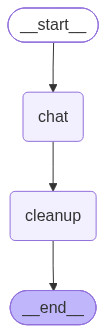

In [8]:
graph

In [9]:
config = {"configurable": {"thread_id": "t1"}}

In [10]:
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Anjali"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)


{'messages': [HumanMessage(content='Now explain checkpointers', additional_kwargs={}, response_metadata={}, id='174d2bab-6612-4afd-a25f-d2e21c2c78b8'),
  AIMessage(content='## Checkpointers in LangGraph – “Save‑and‑Resume” for LLM Workflows\n\n> **TL;DR** – A *checkpoint* is a snapshot of the graph’s state (and optionally, its internal context) that you can write to a durable store and later restore to continue execution from that exact point.  \n\nBelow is a quick‑start guide, the key API bits, and how it fits into a typical LangGraph project.\n\n---\n\n### 1. Why Checkpointers?\n\n| Problem | Checkpointer Solution |\n|---------|-----------------------|\n| **Long‑running graphs** – e.g., multi‑step reasoning that may take minutes and risk timeout or interruption. | Persist the current state after each node; resume if the process dies. |\n| **Retry logic** – you want to retry only the failed node, not the whole graph. | Store the *pre‑node* state; on failure, jump back to that node. |\

In [11]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 6
